<a href="https://colab.research.google.com/github/MedDevouring/moslina-site/blob/main/Copy_of_ELM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# PLAN

# Import data                   DONE
# Verify data integrity         DONE
# Split data train/test/[val]   DONE
# Data pre-processing:
#   * Image Normalisation       DONE
#   * Hand segmentation         DONE
#   * Hand extraction
# Feature extraction
# Classification

# PR curve / confusion matrix

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import random

In [5]:
base_path = "/content/drive/MyDrive/Images-20260421T160931Z-3-001/Images/"
file_path_arr = []
for i in range(4):
  file_path_arr.append(glob.glob(base_path+str(i)+"/*jpg"))
print("All images")
print(file_path_arr)
print("Firts folder")
print(file_path_arr[0])
print("Firts image")
print(file_path_arr[0][0])


All images
[['/content/drive/MyDrive/Images-20260421T160931Z-3-001/Images/0/0.jpg', '/content/drive/MyDrive/Images-20260421T160931Z-3-001/Images/0/2.jpg', '/content/drive/MyDrive/Images-20260421T160931Z-3-001/Images/0/1.jpg', '/content/drive/MyDrive/Images-20260421T160931Z-3-001/Images/0/5.jpg', '/content/drive/MyDrive/Images-20260421T160931Z-3-001/Images/0/3.jpg', '/content/drive/MyDrive/Images-20260421T160931Z-3-001/Images/0/4.jpg', '/content/drive/MyDrive/Images-20260421T160931Z-3-001/Images/0/6.jpg', '/content/drive/MyDrive/Images-20260421T160931Z-3-001/Images/0/7.jpg', '/content/drive/MyDrive/Images-20260421T160931Z-3-001/Images/0/9.jpg', '/content/drive/MyDrive/Images-20260421T160931Z-3-001/Images/0/8.jpg'], ['/content/drive/MyDrive/Images-20260421T160931Z-3-001/Images/1/0.jpg', '/content/drive/MyDrive/Images-20260421T160931Z-3-001/Images/1/1.jpg', '/content/drive/MyDrive/Images-20260421T160931Z-3-001/Images/1/2.jpg', '/content/drive/MyDrive/Images-20260421T160931Z-3-001/Images/1

In [6]:
random.seed(42)

In [7]:
image_index_arr = random.sample(range(0,9),7)
print(image_index_arr)

[1, 0, 5, 2, 8, 4, 7]


In [8]:
train_image_path = []
test_image_path = []

for hand_class in file_path_arr:
  tmp_train = []
  tmp_test = []
  for i in range(10):
    if i not in image_index_arr:
      tmp_test.append(hand_class[i])
    else:
      tmp_train.append(hand_class[i])
  train_image_path.append(tmp_train)
  test_image_path.append(tmp_test)

print(np.shape(train_image_path))
print(np.shape(test_image_path))


(4, 7)
(4, 3)


In [9]:
train_images = []
test_images = []

for cls in train_image_path:
  t = []
  for path in cls:
    t.append(cv2.imread(path))
  train_images.append(t)

for cls in test_image_path:
  t = []
  for i in cls:
    t.append(cv2.imread(i))
  test_images.append(t)

print(np.shape(train_images))
print(np.shape(test_images))

(4, 7, 4032, 1908, 3)
(4, 3, 4032, 1908, 3)


(<Figure size 640x480 with 1 Axes>,
 <matplotlib.image.AxesImage at 0x77ff527153d0>)

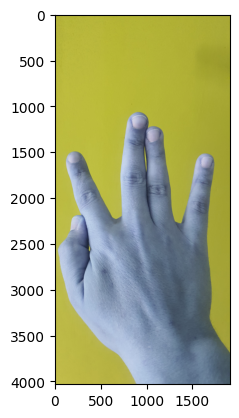

In [10]:
plt.figure(), plt.imshow(train_images[0][0])

(<Figure size 640x480 with 1 Axes>,
 <matplotlib.image.AxesImage at 0x77ff2cd25460>)

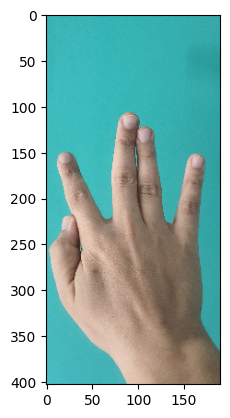

In [12]:
for i, cls in enumerate(train_images):
  for j, image in enumerate(cls):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    width, height, channel = np.shape(image)
    image = cv2.resize(image, (height//10, width//10))
    train_images[i][j] = image
plt.figure(), plt.imshow(train_images[0][0])


(<Figure size 640x480 with 1 Axes>,
 <matplotlib.image.AxesImage at 0x77ff2cd2c9b0>)

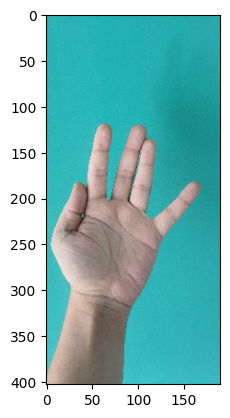

In [13]:
for i, cls in enumerate(test_images):
  for j, image in enumerate(cls):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    width, height, channel = np.shape(image)
    image = cv2.resize(image, (height//10, width//10))
    test_images[i][j] = image
plt.figure(), plt.imshow(test_images[0][0])

In [14]:
def detectie_culoare_piele(img):
    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]

    C1 = np.zeros((img.shape[0], img.shape[1]))
    C2 = np.zeros((img.shape[0], img.shape[1]))
    C3 = np.zeros((img.shape[0], img.shape[1]))
    C4 = np.zeros((img.shape[0], img.shape[1]))
    C5 = np.zeros((img.shape[0], img.shape[1]))
    C6 = np.zeros((img.shape[0], img.shape[1]))
    C7 = np.zeros((img.shape[0], img.shape[1]))
    rez = np.zeros((img.shape[0], img.shape[1]))

    C1[np.logical_and(R > 95, G > 40, B > 20)] = 1
    C2[(np.maximum(np.maximum(R, G), B) - np.minimum(np.minimum(R, G), B)) > 15] = 1
    C3[np.absolute(R - G) > 15] = 1
    C4[np.logical_and(R > G, R > B)] = 1

    C5[np.logical_and(R > 220, G > 210, B > 170)] = 1
    C6[np.absolute(R - G) <= 15] = 1
    C7[np.logical_and(R > B, G > B)] = 1

    caz1 = np.logical_and(np.logical_and(C1 == 1, C2 == 1, C3 == 1), C4 == 1)
    caz2 = np.logical_and(C5 == 1, C6 == 1, C7 == 1)

    rez[np.logical_or(caz1 == 1, caz2 == 1)] = 1

    return rez

In [19]:
train_image_mask = []
for i, cls in enumerate(train_images):
  tmp = []
  for j, image in enumerate(cls):
    tmp.append(detectie_culoare_piele(image))
  train_image_mask.append(tmp)

(<Figure size 640x480 with 1 Axes>,
 <matplotlib.image.AxesImage at 0x77ff2c944230>)

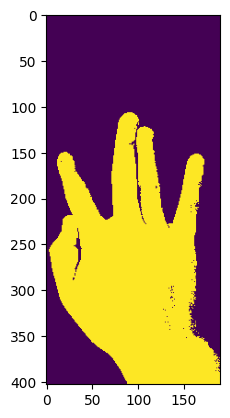

In [20]:
plt.figure(), plt.imshow(train_image_mask[0][0])

In [21]:
test_image_mask = []
for i, cls in enumerate(test_images):
  tmp = []
  for j, image in enumerate(cls):
    tmp.append(detectie_culoare_piele(image))
  test_image_mask.append(tmp)

(<Figure size 640x480 with 1 Axes>,
 <matplotlib.image.AxesImage at 0x77ff2cd26930>)

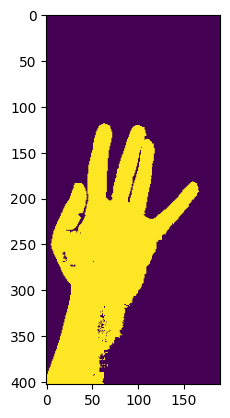

In [22]:
plt.figure(), plt.imshow(test_image_mask[0][0])